In [ ]:
import sys
sys.path.append('/home/carroll/Documents/')

import numpy as np
import os
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import scipy.io as scio
from scipy.signal import savgol_filter
import asdprocessor
import asd_jump_correction

os.chdir('/home/carroll/Documents/')

# %matplotlib widget

In [ ]:
# prep in situ spectra for calibration tarps
dir_insitu = '/store/carroll/col/data/2018/insitu/'
fp = glob(os.path.join(dir_insitu, f'KBDU_*', 'Data', f'KBDU_*_Refl.dat'))[0]
wavelengths = np.genfromtxt(fp, skip_header=3)[:,0]
wl_nan = np.loadtxt('/store/carroll/col/data/2025/wl_nan.txt')

wl_asd = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_asd.txt')[:,0]
wl_neon = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_neon.txt')[:,1]
fwhm_neon = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_neon.txt')[:,2]


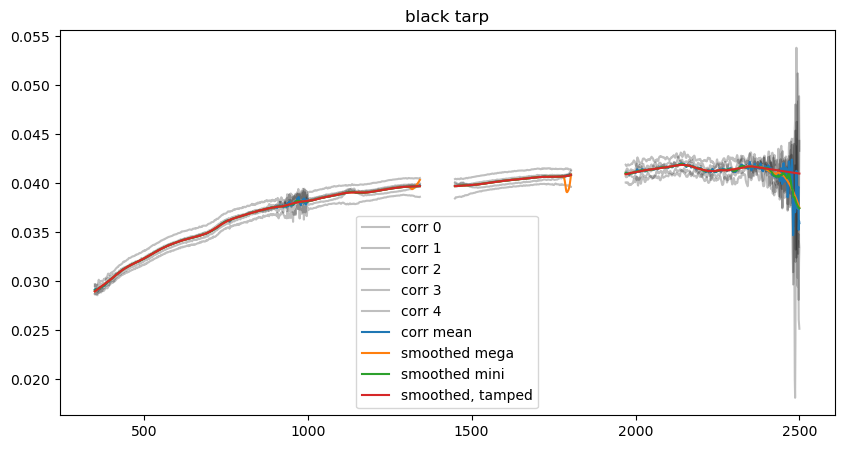

In [ ]:
# black tarp

fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
insitu = np.empty((len(fps),wl_nan.shape[0]))
for i in range(len(fps)):
    rfl_ = np.genfromtxt(fps[i], skip_header=3)[:,1]
    insitu[i,:] = rfl_

# jump correction
insitu_jumpcorr = insitu.copy()
jump_corr_method = 'asdparabolic'
jump_corr_iterations = 3
asd_coeff_path = './correction_data/asd_temp_corr_coeffs.mat'
negatives_corr_method='parabolic'
interpolate_H2O=False,
interpolate_H2O_method='parabolic'
coeff_data = scio.loadmat(asd_coeff_path)
asd_coeffs = coeff_data['asd_temp_corr_coeffs']
for i in range(insitu.shape[0]):
    rfl_ = insitu[i,...]
    corr_output = asd_jump_correction.asd_jump_correction(asd_coeffs, rfl_, wavelengths,
                                      jump_corr_method = jump_corr_method,
                                      iterations=jump_corr_iterations,
                                      negatives_corr_method = negatives_corr_method,
                                      interpolate_H2O = interpolate_H2O,
                                      interpolate_H2O_method = interpolate_H2O_method) 
    insitu_jumpcorr[i,...] = corr_output[0] # spectrum only
rfl_mean = np.mean(insitu_jumpcorr, axis=0)

# smooth
i1280 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1280)[0]
i1450 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1450)[0]
i1750 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1750)[0]
i1970 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1970)[0]
smoothed_mini = savgol_filter(rfl_mean, window_length=31, polyorder=2)
smoothed_mega = savgol_filter(rfl_mean, window_length=101, polyorder=2) # very very strong filter lol
smoothed_black = np.concatenate([smoothed_mega[0:i1280],
                                 smoothed_mini[i1280:i1450],
                                 smoothed_mega[i1450:i1750],
                                 smoothed_mini[i1750:i1970],
                                 smoothed_mega[i1970:]
                          ])


# manual corrections at swir2
swir2max = np.max(smoothed_black[wavelengths > 2300])
swir2max_idx = np.argmax((wavelengths > 2300) & (smoothed_black == swir2max))
smoothed_black[swir2max_idx:] = np.linspace(swir2max, 0.041, len(wavelengths)-swir2max_idx)

fig = plt.figure(figsize=(10,5))
for i in range(insitu_jumpcorr.shape[0]):
    rfl_corr = insitu_jumpcorr[i,...]
    plt.plot(wl_nan, rfl_corr, c='black', label=f'corr {i}', alpha=0.25)

plt.plot(wl_nan, rfl_mean, label='corr mean')

plt.plot(wl_nan, smoothed_mega, label='smoothed mega')
plt.plot(wl_nan, smoothed_mini, label='smoothed mini')
plt.plot(wl_nan, smoothed_black, label='smoothed, tamped')

plt.title('black tarp')
plt.legend()
plt.show()

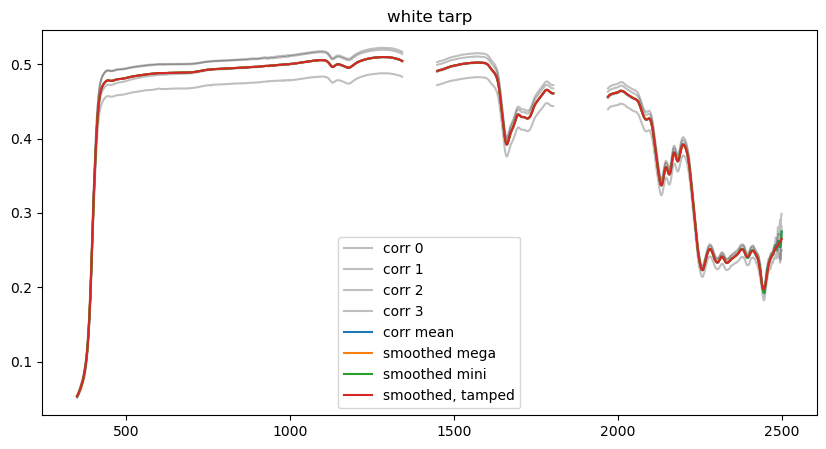

In [ ]:
# white tarp

fps = sorted(glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat')))
del fps[2] # drop the 2nd file as an outlier

insitu = np.empty((len(fps),wl_nan.shape[0]))
for i in range(len(fps)):
    rfl_ = np.genfromtxt(fps[i], skip_header=3)[:,1]
    insitu[i,:] = rfl_

# jump correction
insitu_jumpcorr = insitu.copy()
jump_corr_method = 'asdparabolic'
jump_corr_iterations = 3
asd_coeff_path = './correction_data/asd_temp_corr_coeffs.mat'
negatives_corr_method='parabolic'
interpolate_H2O=False,
interpolate_H2O_method='parabolic'
coeff_data = scio.loadmat(asd_coeff_path)
asd_coeffs = coeff_data['asd_temp_corr_coeffs']
for i in range(insitu.shape[0]):
    rfl_ = insitu[i,...]
    corr_output = asd_jump_correction.asd_jump_correction(asd_coeffs, rfl_, wavelengths,
                                      jump_corr_method = jump_corr_method,
                                      iterations=jump_corr_iterations,
                                      negatives_corr_method = negatives_corr_method,
                                      interpolate_H2O = interpolate_H2O,
                                      interpolate_H2O_method = interpolate_H2O_method) 
    insitu_jumpcorr[i,...] = corr_output[0] # spectrum only

rfl_mean = np.mean(insitu_jumpcorr, axis=0)

# smooth
i2340 = asd_jump_correction.get_closest_wvl_index(wavelengths, 2340)[0]
smoothed_mini = savgol_filter(rfl_mean, window_length=7, polyorder=3)
smoothed_mega = savgol_filter(rfl_mean, window_length=31, polyorder=2)
smoothed_white = np.concatenate([smoothed_mini[0:i2340],
                                 smoothed_mega[i2340:]
                          ])

# manual corrections at swir2
swir2max = np.max(smoothed_white[wavelengths > 2300])
swir2max_idx = np.argmax((wavelengths > 2300) & (smoothed_white == swir2max))
smoothed_white[swir2max_idx:] = np.linspace(swir2max, 0.041, len(wavelengths)-swir2max_idx)

fig = plt.figure(figsize=(10,5))
for i in range(insitu_jumpcorr.shape[0]):
    rfl_corr = insitu_jumpcorr[i,...]
    plt.plot(wl_nan, rfl_corr, c='black', label=f'corr {i}', alpha=0.25)

plt.plot(wl_nan, rfl_mean, label='corr mean')

plt.plot(wl_nan, smoothed_mega, label='smoothed mega')
plt.plot(wl_nan, smoothed_mini, label='smoothed mini')
plt.plot(wl_nan, smoothed_white, label='smoothed, tamped')

plt.title('white tarp')
plt.legend()
plt.show()

In [ ]:
# export
fol = '/store/carroll/col/2018/insitu/'
out = np.vstack([smoothed_white, smoothed_black])
out = pd.DataFrame(out, columns=wavelengths)
out['year']=2018
out['site']=['white_tarp','black_tarp']

# asd wvl
for idx, row in out.iterrows():
    fp_out = fol+f'cal_{row['site']}.txt'
    rfl = row[0:2151]  
    tmp = np.stack([wavelengths, rfl], axis=1)
    np.savetxt(fp_out, tmp)

# neon wvl
fps = glob('/store/carroll/col/data/2018/insitu/cal*.txt', recursive=True)
fps = [x for x in fps if 'neon' not in x]
for fp in fps:
    rfl_asd = np.loadtxt(fp)[:,1]
    rfl_neon = np.zeros_like(wl_neon)
    for i, (center, fwhm) in enumerate(zip(wl_neon, fwhm_neon)):
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))  # Convert FWHM → Gaussian σ
        weights = np.exp(-0.5 * ((wl_asd - center) / sigma)**2)
        weights /= np.sum(weights)               # Normalize weights
        rfl_neon[i] = np.sum(rfl_asd * weights)     # Weighted average
    rfl_neon = np.stack([wl_neon, rfl_neon], axis=1)
    np.savetxt(fp.replace('.txt', '_neon.txt'), rfl_neon)